# An Overview of R

**HS 821 · Lecture 1**  
**Sunil Paul** · 4 August 2026 · R 4.5.3

These notes introduce the R language: how to run it, how its objects and data structures work, how to import data, how to control program flow, and how to write your own functions. 

## Setup

These notes assume a working R installation with the packages used below.

**Software.** Install R from [CRAN](https://cran.r-project.org). Most people also use an interface such as [RStudio](https://posit.co/download/rstudio-desktop/). To run these notes as a Jupyter notebook you additionally need the **IRkernel** package, registered once with `IRkernel::installspec()`.

**Packages.** This lecture uses only packages that ship with R: `datasets` and `MASS`. If a package is missing, install it once with `install.packages("MASS")` and load it with `library(MASS)`.

## Overview of R

R is a free, open-source language and environment for statistical computing and graphics. It runs on almost every platform, has a clean and intuitive syntax, and is backed by a large, active community, so help is easy to find. R is user-extensible: anyone can write extensions and share them with others.

R is built around **packages** — collections of functions, data, and documentation. The `base` system that ships with R already includes the essential packages, and thousands more (over 20,000 on CRAN today) extend it into almost every area of data analysis.

## Installing and loading packages

You can install a package through a menu (in RStudio, *Tools ▸ Install Packages…*) or from the console with `install.packages("package_name")`. Installation is a one-time step. In each new session you make a package available by loading it with `library("package_name")` or `require("package_name")`.

## R commands and syntax

R's syntax is deliberately simple. The console shows a `>` prompt when it is ready for a command; if a command is incomplete, the prompt changes to `+` to show that R is waiting for the rest of the input. Values are assigned to names with the `<-` operator, comments begin with `#`, and names are case-sensitive (`x` and `X` are different objects). Functions are called by writing the function name followed by its arguments in parentheses: `functionname(arg1, arg2, ...)`.

## Objects in R

Everything created in R is stored as an object. An object may contain a number, text, logical values, a data set, a function, or another kind of information.

For example, the following statement creates an object named `x` and assigns the value `42` to it.

In [19]:
x <- 42

Several functions help us understand what an object contains.

In [20]:
cat("Mode   :", mode(x), "\n")
cat("Type   :", typeof(x), "\n")
cat("Class  :", class(x), "\n")
cat("Length :", length(x), "\n")

str(x)

Mode   : numeric 
Type   : double 
Class  : numeric 
Length : 1 
 num 42


For the object`x`:

- `mode(x)` returns `"numeric"`, a broad description of the object.
- `typeof(x)` returns `"double"`, which is the internal storage type used by R.
- `class(x)` returns `"numeric"`, which describes how R treats the object.
- `length(x)` returns `1`, because the object contains one element.
- `str(x)` gives a compact summary: `x` is a numeric object containing the value `42`

## Working directory and workspace

The objects you create live in an in-memory **workspace**. The **working directory** is the folder on disk that R reads from and writes to by default, so it is where a saved workspace is stored and loaded from.

A few commands manage all of this. `getwd()` returns the current working directory and `setwd("path/to/folder")` changes it. `ls()` lists the objects in the workspace and `rm(list = ls())` removes them all. `save.image("intro1.Rdata")` saves the whole workspace to a file and `load("intro1.Rdata")` restores it, while `dir()` lists the files in the working directory.

## Getting help in R

R has extensive built-in help. Use `help(function)` or the shortcut `?function` to open a function's documentation, and `args(function)` to see just its arguments. When you don't know the exact name, `help.search("topic")` searches the installed packages and `RSiteSearch("topic")` searches online resources.

## Functions in R

R works by calling functions. A function takes **arguments** as input and returns a **value** as output; both the inputs and the output are themselves objects. Some functions come with base R, and others arrive with the packages you load.A function call normally has the following form:`function_name(argument1, argument2)`.

For example, log() calculates a logarithm.


In [21]:
log(100)                  # Natural logarithm
log(100, base = 10)       # Base-10 logarithm
log10(100)                # Specialised base-10 function
log(100, b = 10)          # Partial argument matching

[1] 4.60517

[1] 2

[1] 2

[1] 2

Arguments can be supplied by position or by name. `log(100, base = 10)` names the second argument explicitly. R also allows *partial* matching of argument names, which is why `log(100, b = 10)` works — but partial names are fragile and best avoided in code you intend to keep.

## Data types

Every value in R has a type. The most common are **logical** (`TRUE`, `FALSE`), **integer** (whole numbers), **double** (floating-point numbers such as `1.23e6`), and **character** (text strings). R also has special values for missing or undefined data: `NA` marks a missing value, and `NaN` ("not a number") results from undefined operations such as `0/0`.

### The R console

The primary way to interact with R is through the console: you type a command, press Enter, and R prints the result. Graphical environments such as RStudio are conveniences built on top of this same console. The examples below show R evaluating arithmetic, comparisons, and type checks one expression at a time.
R uses the usual arithmetic operators: `+`, `-`, `*`, `/`, and `^`. Parentheses can be used to control the order of calculation.

In [22]:
2 + 4
2 - 4
2 * 4
2 / 4
2 ^ 4
2 %% 4

[1] 6

[1] -2

[1] 8

[1] 0.5

[1] 16

[1] 2

Text values are called character data and must be enclosed in quotation marks

In [23]:
"Hello"

[1] "Hello"

Some mathematical operations are not defined within the real numbers.

In [24]:
sqrt(-17)

Warning message in sqrt(-17):
"NaNs produced"


[1] NaN

R returns `NaN` when a numerical result is undefined. It also displays a warning explaining the problem. A complex result can be obtained using `sqrt(-17 + 0i)`

In [25]:
sqrt(-17 + 1i)

[1] 0.1212154+4.124887i

Comparison operators test whether a condition is true or false. The result is a logical value: TRUE or FALSE.

In [26]:
7 > 5
7 < 5
7 >= 7

[1] TRUE

[1] FALSE

[1] TRUE

In [27]:
7 == 5 # test equality
7 != 5 # test inequality

[1] FALSE

[1] TRUE

Logical operators combine conditions. The operator `&` means “and,” while `|` means “or.”

In [28]:
(5 > 7) & (6*7 == 42)
(5 > 7) | (6*7 == 42)

[1] FALSE

[1] TRUE

Functions beginning with `is`. test whether an object has a particular property and return `TRUE` or` FALSE`.

In [29]:
is.numeric(7)
is.na(7/0)
is.na(0/0)
is.character(7)
is.character("seven")

[1] TRUE

[1] FALSE

[1] TRUE

[1] FALSE

[1] TRUE

Functions beginning with `as.` convert an object from one type to another. Unlike `is.` functions, they return a converted value rather than
`TRUE` or `FALSE`.

In [30]:
as.character(5/6)       # Convert a number to text
as.numeric("0.833333")  # Convert numeric text to a number

[1] "0.833333333333333"

[1] 0.833333

## Data structures

R organises data into structures that differ by their number of dimensions and by whether they hold one type of element or several. **Vectors** and **lists** are one-dimensional; **matrices** and **data frames** are two-dimensional; **arrays** can have any number of dimensions. A structure is *homogeneous* if every element must share the same type (vectors, matrices, arrays) and *heterogeneous* if it may mix types (lists, data frames).

### Vectors

A vector is the most basic R data structure: an ordered, one-dimensional collection of elements that all share the same type. The `c()` function ("combine") builds one.
The following examples create vectors containing different types of values.

In [31]:
x <- c(1, 2, 3)
x1 <- c(0.5, 0.6)
x2 <- c(TRUE, FALSE)
x3 <- c("a", "b", "c")
x4 <- 9:29
x5 <- c(1 + 0i, 2 + 4i)

In [32]:
str(x)

 num [1:3] 1 2 3


`str()` displays the internal structure of an object. Here, `x` is a numeric vector containing three elements.

### Matrices

A matrix is a two-dimensional, homogeneous structure. You can build one with `matrix()`, turn a vector into a matrix by giving it a `dim` attribute, or bind vectors together as columns (`cbind()`) or rows (`rbind()`).

Here, we specify two rows and four columns without supplying any values, so R fills the cells with `NA`.

In [33]:
m <- matrix(nrow = 2, ncol = 3)
m

NA,NA,NA
NA,NA,NA


`dim()` returns the number of rows and columns.  
`attributes()` displays the matrix dimensions stored by R.

In [34]:
dim(m)
attributes(m)

[1] 2 3

$dim
[1] 2 3

When values are supplied, R fills the matrix column by column by default.

In [35]:
m <- matrix(1:6, ncol = 2, nrow = 3)
m

1,4
2,5
3,6


A vector can be converted into a matrix by assigning its dimensions using `dim()`.

In [36]:
m <- 1:4
dim(m) <- c(2, 2)
m

1,3
2,4


`cbind()` combines objects as columns, whereas `rbind()` combines them as rows.

In [37]:
x <- 1:3
y <- 4:6

In [38]:
m <- cbind(x, y)
m

x,y
1,4
2,5
3,6


In [39]:
m <- rbind(x, y)
m

x,1,2,3
y,4,5,6


### Lists

A list is one-dimensional but *heterogeneous*: each element can be a different type, and can itself be another structure such as a vector or another list. This makes lists the natural container for grouping related but dissimilar pieces of data.

In [40]:
x <- list(1:3, "a", c(TRUE, FALSE, TRUE), c(2.3, 5.9))
str(x)


List of 4
 $ : int [1:3] 1 2 3
 $ : chr "a"
 $ : logi [1:3] TRUE FALSE TRUE
 $ : num [1:2] 2.3 5.9


### Data frames

A data frame is the workhorse structure for tabular data. It is two-dimensional like a matrix, but each column may have its own type, so one column can be numeric while another is character. Each column is a variable and each row is an observation.


In [41]:
df1 <- data.frame(x = 1:3, y = 4:6)

In [42]:
df1

x,y
<int>,<int>
1,4
2,5
3,6


### Examining the structure

A data frame is internally stored as a list of equal-length vectors.

- `typeof()` shows the internal storage type.
- `str()` gives a compact description of the columns.
- `attributes()` displays names, row names, and class information.

  Although a data frame appears as a table, R internally stores it as a list in which each column is one component.

Here, `x` is numeric and `y` is character. Both can be combined because they contain the same number of elements.

In [43]:
x <- 1:3
y <- c("a", "b", "c")
df2 <- data.frame(x, y)

In [44]:
df2

x,y
<int>,<chr>
1,a
2,b
3,c


Data-frame elements can be selected using the column name or their row and column positions.

In [47]:
df1$x       # Select column x by name
df1[1, ]    # Select the first row
df1[, 1]    # Select the first column
df1[1, 1]   # Select the value in row 1, column 1

[1] 1 2 3

,x,y
,<int>,<int>
1,1,4


[1] 1 2 3

[1] 1

Inside the square brackets, the position before the comma identifies rows and the position after the comma identifies columns:

`data_frame[rows, columns]`

Two convenience functions are worth knowing but using with care. `attach(df)` lets you refer to a data frame's columns by name alone, but it can cause confusing name clashes and is generally discouraged in favour of `df$column` or `with()`. `fix(df)` and `data.entry(df)` open a simple spreadsheet-style editor for a data frame.
Different functions describe different aspects of the object:

- `length()` returns the number of columns.
- `typeof()` shows its internal storage type.
- `class()` identifies it as a data frame.
- `summary()` provides descriptive statistics for each column.

In [48]:
summary(df1)

       x             y      
 Min.   :1.0   Min.   :4.0  
 1st Qu.:1.5   1st Qu.:4.5  
 Median :2.0   Median :5.0  
 Mean   :2.0   Mean   :5.0  
 3rd Qu.:2.5   3rd Qu.:5.5  
 Max.   :3.0   Max.   :6.0  

In [49]:
attributes(df1)

$names
[1] "x" "y"

$class
[1] "data.frame"

$row.names
[1] 1 2 3

## Importing data

Most real analyses start by reading data from a file. `read.csv()` reads comma-separated files and `read.table()` reads more general delimited files; both return a data frame. To keep these notes reproducible, the example below writes a built-in data set to a temporary CSV and reads it straight back — in your own work you would instead point `read.csv()` at your file, e.g. `read.csv("mydata.csv")`.

In [1]:
# R reads tabular files with read.csv() and read.table().
# To keep this example self-contained, write a small CSV to a temporary
# file, then read it back in.

tmp <- tempfile(fileext = ".csv")
write.csv(mtcars, tmp, row.names = TRUE)

data <- read.csv(tmp)
head(data, 2)
tail(data, 2)

,X,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
1,Mazda RX4,21,6,160,110,3.9,2.620,16.46,0,1,4,4
2,Mazda RX4 Wag,21,6,160,110,3.9,2.875,17.02,0,1,4,4


,X,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<int>,<int>,<int>,<int>
31,Maserati Bora,15.0,8,301,335,3.54,3.57,14.6,0,1,5,8
32,Volvo 142E,21.4,4,121,109,4.11,2.78,18.6,1,1,4,2


### Practice: sheep measurements

Try the following in R :

1. Create a vector of sheep weights (kg) from the sample 84.5, 72.6, 75.7, 94.8, 71.3, and find its sum, mean, and length.
2. Create a second vector of heights: 86.5, 71.8, 77.2, 84.9, 75.4.
3. Combine weight and height into a data frame called `sheep`, then add a third column, `backlength`: 130.4, 100.2, 109.4, 140.6, 101.4.
4. Generate descriptive statistics for the data frame.
5. Fit a regression of weight on height.

### Subsetting
The examples below build a richer data frame from R's built-in `state` data.
You select parts of a data frame with square brackets, `df[rows, columns]`. Rows and columns can be given by position (a numeric index), by name, or by a logical condition that keeps the rows where it is `TRUE`. Leaving one side of the comma blank keeps all of that dimension.

In [2]:
library(datasets)

In [3]:
head(state.x77, 2)
tail(state.x77, 2)

,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
Alabama,3615,3624,2.1,69.05,15.1,41.3,20,50708
Alaska,365,6315,1.5,69.31,11.3,66.7,152,566432


,Population,Income,Illiteracy,Life Exp,Murder,HS Grad,Frost,Area
Wisconsin,4589,4468,0.7,72.48,3.0,54.5,149,54464
Wyoming,376,4566,0.6,70.29,6.9,62.9,173,97203


We first inspect the built-in datasets and then combine them into one data frame. `head()` displays the first observations, while `tail()` displays the last observations.

In [4]:
states <- data.frame(
  state.x77,
  abb = state.abb,
  region = state.region,
  division = state.division
)

colnames(states)

[1] "Population" "Income"     "Illiteracy" "Life.Exp"   "Murder"    
 [6] "HS.Grad"    "Frost"      "Area"       "abb"        "region"    
[11] "division"

The new data frame contains numerical state indicators together with the state abbreviation, region, and division. `colnames()` shows the names available for selecting variables.

The general form is `data[rows, columns]`. Here, `40` identifies the row and `4` identifies the column. The result is one individual value.

In [5]:
states[49, 3]  # By row and column index

[1] 0.7

Rows and columns can also be selected by name. This is usually easier to read than selecting by numerical position.

In [6]:
states["Wisconsin", "Illiteracy"]  # By row and column name

[1] 0.7

Leaving the column position empty selects all columns. Therefore, the following command returns all available information for Wisconsin.

In [7]:
states["Wisconsin", ]  # Entire row for Wisconsin

,Population,Income,Illiteracy,Life.Exp,Murder,HS.Grad,Frost,Area,abb,region,division
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<fct>,<fct>
Wisconsin,4589,4468,0.7,72.48,3,54.5,149,54464,WI,North Central,East North Central


A logical condition can be placed in the row position. R keeps rows for which the condition evaluates to `TRUE`.

In [8]:
states[states$division == "New England", "Illiteracy"]

[1] 1.1 0.7 1.1 0.7 1.3 0.6

This selects the illiteracy values of states belonging to the New England division.
The same method can be used with another categorical variable. Here, we select illiteracy values for states in the South region.

In [9]:
states[states$region == "South", "Illiteracy"]

[1] 2.1 1.9 0.9 1.3 2.0 1.6 2.8 0.9 2.4 1.8 1.1 2.3 1.7 2.2 1.4 1.4

Before defining a condition, it is useful to examine the distribution of the variable. `summary()` reports the minimum, quartiles, median, mean, and maximum.

In [10]:
summary(states$HS.Grad)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  37.80   48.05   53.25   53.11   59.15   67.30 

In [11]:
states$HS.Grad <- states$HS.Grad / 100

In [89]:
summary(states$HS.Grad)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
 0.3780  0.4805  0.5325  0.5311  0.5915  0.6730 

`HS.Grad` is recorded as a percentage. Dividing by 100 converts the values from percentages to proportions between 0 and 1.

In [90]:
states$HS.Grad <- 100 * states$HS.Grad

We can combine variables to construct a new measure. Since `100 - Illiteracy` represents the literacy rate, the following expression calculates the high-school graduation rate relative to the literate population.

In [92]:
with(states, head(100 * (HS.Grad / (100 - Illiteracy))))

[1] 42.18590 67.71574 59.16497 40.67278 63.29626 64.35045

This example demonstrates arithmetic operations on columns. The resulting ratio should be interpreted cautiously because the variables may refer to different population groups.

We now examine whether states experiencing more frost days tend to have different illiteracy rates. In the formula `Illiteracy ~ Frost`, `Frost` is placed on the horizontal axis and `Illiteracy` on the vertical axis.

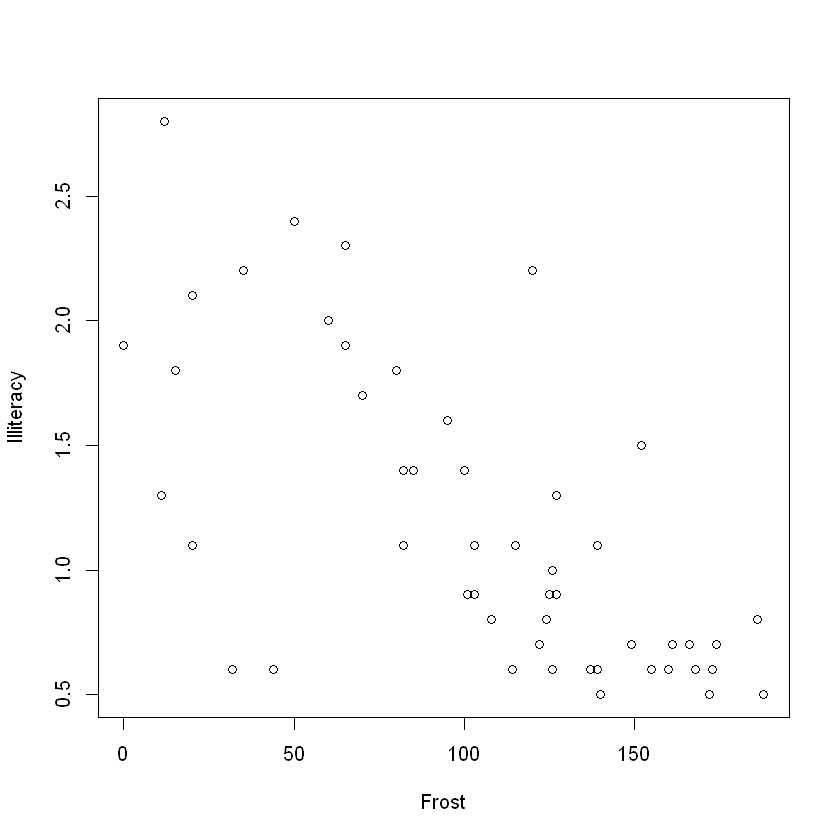

In [93]:
plot(Illiteracy ~ Frost, data = states)

### Practice: exploring a data frame

Use the built-in `airquality` data set (it loads with the `datasets` package, so no import is needed):

1. How many rows and columns does it have? (`nrow()`, `ncol()`, `dim()`)
2. What are the names of its columns? (`names()`)
3. What is the value in row 5, column 4?
4. Display the second row in full.


### Practice: the Cars93 data set

The `Cars93` data set comes with the `MASS` package. Load it with `library(MASS)`, then explore:

1. Inspect it with `View(Cars93)` and summarise it with `summary(Cars93)`.
2. What is the minimum horsepower among cars with a 7-passenger capacity?
3. What about cars with a capacity of at least 6 passengers?
4. What is the mean price of rear-wheel-drive cars?

## Control structures

Control structures direct the flow of execution through a program. R's main ones are `if`/`else` for choosing between branches, `for` and `while` for repetition, and the less common `repeat`. The sections below take them in turn.

### if and else

An `if` statement runs a block of code only when a condition is `TRUE`, and an optional `else` block runs otherwise. The condition must evaluate to a single `TRUE` or `FALSE` value.

```r
if (condition) {
  ## runs when condition is TRUE
} else {
  ## runs when condition is FALSE
}
```

In [9]:
x <- 3

if (x > 5) {
  print("x is greater than 5")
} else {
  print("x is 5 or less")
}


[1] "x is 5 or less"


In [14]:
fun1 <- function(x){if (x > 50) {
  print("x is greater than 50")
} else {
  print("x is 50 or less")
}}

In [17]:
fun1(51)


[1] "x is greater than 50"


### Nested if

Because the body of an `else` can contain another `if`, you can nest conditions to any depth to distinguish more than two cases.

```r
if (condition1) {
  ## expression
} else {
  if (condition2) {
    ## expression
  } else {
    ## expression
  }
}
```

In [ ]:
x <- 7

if (x > 10) {
  print("x > 10")
} else {
  if (x > 5) {
    print("5 < x <= 10")
  } else {
    print("x <= 5")
  }
}


## Iteration

Iteration automates a multi-step process: you group the actions that need to be repeated and let R run through them for you.

### The for loop

A `for` loop steps a counter (here `i`) through the elements of a vector and runs its body once for each element — it *iterates over the vector*. It is the natural choice when you know in advance how many times to repeat.

In [10]:
table.of.logarithms <- vector(length = 7, mode = "numeric")
table.of.logarithms

[1] 0 0 0 0 0 0 0

In [94]:
for (i in 1:length(table.of.logarithms)) {
  table.of.logarithms[i] <- log(i)
}
table.of.logarithms

[1] 0.0000000 0.6931472 1.0986123 1.3862944 1.6094379 1.7917595 1.9459101

### Nested loops

One loop nested inside another visits every cell of a two-dimensional structure. Here we fill a 9 × 9 matrix so that each entry is the product of its row and column indices — a multiplication table.

In [ ]:
# Build a 9 x 9 matrix whose entry [i, j] is i * j (a multiplication table)
mymat <- matrix(nrow = 9, ncol = 9)

for (i in 1:nrow(mymat)) {
  for (j in 1:ncol(mymat)) {
    mymat[i, j] <- i * j
  }
}

mymat

### Nested loops with a 3-D array

The same idea extends to more dimensions. Here three nested loops fill a 3 × 3 × 3 array so that each entry is the product of its three indices.

In [ ]:
# Build a 3 x 3 x 3 array whose entry [i, j, k] is i * j * k
my_array <- array(0, dim = c(3, 3, 3))

for (i in 1:dim(my_array)[1]) {
  for (j in 1:dim(my_array)[2]) {
    for (k in 1:dim(my_array)[3]) {
      my_array[i, j, k] <- i * j * k
    }
  }
}

my_array

> **The R way.** Explicit loops like these are clear for learning, but R is usually faster and more idiomatic when you *vectorise* — operating on whole vectors at once — or use the `apply` family (`apply()`, `sapply()`, `lapply()`). The entire multiplication table above, for instance, is just `outer(1:9, 1:9)`. See the [Vectorization and the apply family](#Vectorization-and-the-apply-family) section below.

### The while loop

A `while` loop repeats its body as long as a condition stays `TRUE`. As with `if`, the condition must be a single Boolean value. Use `while` when you can recognise when to stop but cannot say in advance how many iterations that will take. Two cautions follow: the body never runs at all if the condition starts out `FALSE`, and it runs forever if the condition never becomes `FALSE`, so the body must make progress toward stopping.

```r
while (condition) {
  ## expressions
}
```

#### Example: Fibonacci numbers with while

Each Fibonacci number is the sum of the previous two. This loop prints terms until the value reaches 50.

In [97]:
### while Loop (Fibonacci example)
### Generate first few Fibonacci numbers: 0, 1, 1, 2, 3, 5, 8, 13, … where each number is the sum of the previous two numbers.
a <- 0
b <- 1
print(a)

while (b < 50) {
  print(b)
  temp <- a + b
  a <- b
  b <- temp
}

[1] 0
[1] 1
[1] 1
[1] 2
[1] 3
[1] 5
[1] 8
[1] 13
[1] 21
[1] 34


#### Building up a vector with while

This loop grows a vector one element at a time, stopping once it reaches length 10 — a length-driven condition rather than a value-driven one.

In [ ]:
x <- c(0, 1)

while (length(x) < 10) {
  position <- length(x)
  new <- x[position] + x[position - 1]
  x <- c(x, new)
}
x


### for versus while

Use a `for` loop when the number of repetitions — the set of values to iterate over — is known in advance. Use a `while` loop when you can tell when to stop only once you get there, even if you couldn't predict it beforehand. In principle every `for` loop can be rewritten as a `while` loop, but the `for` version is usually clearer when it applies.

## User-defined functions

Writing your own functions lets you package repetitive steps and reuse them. You create a function with the `function()` directive and store it in a name, exactly like any other object. Functions are themselves objects, so they can be passed as arguments to other functions and defined inside one another. A function returns the value of the last expression evaluated in its body, or whatever you pass to `return()`.

Objects created inside a function are **local**: they live in the function's own environment and do not exist outside it. To make a result available to the rest of your program, return it.

```r
name.of.function <- function(arg1, arg2) {
  statements
  return(result)
}
```

### Example: squaring

In [18]:
square.it <- function(x) {
  square <- x * x
  return(square)
}

In [19]:
square.it(5)

[1] 25

In [20]:
square.it(c(1, 4, 2))

[1]  1 16  4

In [101]:
square.it(matrix(c(3, 4, 10, 5), nrow = 2))

9,100
16,25


### return() and local scope

The objects created inside a function stay in its local environment and will not appear in your global workspace; only the value you `return()` comes back to the caller. The next two functions show the difference: `fun1()` returns `w` explicitly, while `fun2()` computes `y` but never returns it — so calling it produces no visible result.

In [27]:
fun1 <- function(x) {
  y <- 3 * x - 1
z <- 5*x+3
w <- y*z
    return(w)
}

In [28]:
fun1(5)

[1] 392

In [104]:
fun2 <- function(x) {
  y <- 3 * x - 1
}

In [105]:
fun2(5)

### Calling other functions

A function can take several arguments and call other functions inside its body. The example below takes three arguments — a matrix, a vector, and a scalar — squares the scalar with the `square.it()` function defined earlier, multiplies the matrix by the vector, and multiplies those two results together before returning the final object.

In [106]:
my.fun <- function(X.matrix, y.vec, z.scalar) {
  sq.scalar <- square.it(z.scalar) # use my previous function square.it() to square the scalar and save result
  mult <- X.matrix %*% y.vec # use my previous function square.it() to square the scalar and save result
  final <- mult * sq.scalar # multiply the two resulting objects together to get a final object
  return(final) # return the result
}

In [106]:
# save a matrix and a vector object
my.mat <- cbind(c(1, 3, 4), c(5, 4, 3))
my.vec <- c(4, 3)

# pass my.mat and my.vec into the my.fun function
my.fun(my.mat, my.vec, 9)

1539
1944
2025


### Returning several values in a list

A function can return only one object, so to hand back several results you bundle them into a list. Here the function returns both a transposed matrix and an element-wise squared vector; the caller pulls them apart afterwards with the `[[ ]]` operator.

In [107]:
another.fun <- function(sq.matrix, vector) {
    # transpose matrix and square the vector
  step1 <- t(sq.matrix)
  step2 <- vector * vector
    
    # save both results in a list and return
  final <- list(step1, step2)
  return(final)
}
# call the function and save result in object called outcome
outcome <- another.fun(cbind(c(1, 2), c(3, 4)), c(2, 3))
# Now to separate those objects for use in your further code, you can extract them using the [[#]] operator:
outcome[[1]]  # Transposed matrix
outcome[[2]]  # Squared vector


1,2
3,4


[1] 4 9

### Debugging and sanity checks

When a function runs several statements, something can go wrong partway through. R evaluates the body one statement at a time and stops at the first error, so the trick is to find *where* it stopped. In the function below the dimensions matter: you cannot multiply matrices whose dimensions do not conform, so passing a vector of the wrong length triggers an error.

In [109]:
my.fun <- function(X.matrix, y.vec, z.scalar) {
  print("Matrix:")
  print(X.matrix)
  print("Vector:")
  print(y.vec)
  print("Dimensions:")
  print(dim(X.matrix))
  print(length(y.vec))
  
  sq.scalar <- square.it(z.scalar)
  print(paste("sq.scalar =", sq.scalar))
  
  mult <- X.matrix %*% y.vec
  final <- mult * sq.scalar
  
  return(final)
}

The call below **is expected to fail**: `my.mat` has two columns but `y.vec` has five elements, so `X.matrix %*% y.vec` is non-conformable. The `print()` statements show how far execution got before the error.

In [110]:
my.fun(X.matrix = my.mat, y.vec = c(2, 3, 6, 4, 1), z.scalar = 9)

[1] "Matrix:"
     [,1] [,2]
[1,]    1    5
[2,]    3    4
[3,]    4    3
[1] "Vector:"
[1] 2 3 6 4 1
[1] "Dimensions:"
[1] 3 2
[1] 5
[1] "sq.scalar = 81"


ERROR: Error in X.matrix %*% y.vec: non-conformable arguments


In [ ]:
# When a function stops with an error, traceback() shows the call stack that
# led to it, which helps locate the problem:
traceback()

# For step-by-step interactive debugging in RStudio or the R console you would
# use debug(my.fun) and then call the function, stepping through it line by line.
# debug() is interactive, so it is not run here.

A cleaner approach is *defensive programming*: check the inputs at the top of the function and stop with a helpful message if they are wrong, rather than letting R fail deeper in with a cryptic error. `stop()` (and `stopifnot()`) do exactly this.

In [111]:
my.second.fun <- function(matrix, vector) {
  if (dim(matrix)[2] != length(vector)) {
    stop("Dimension mismatch: can't multiply matrix %*% vector")
  }
  return(matrix %*% vector)
}

In [111]:
my.second.fun(my.mat, c(6, 5))       # Works

The next call passes a length-3 vector to a function expecting length 2, so the guard triggers and stops with our custom message — an expected, deliberate error.

In [111]:
my.second.fun(my.mat, c(6, 5, 7))    # Triggers error

31
38
39


ERROR: Error in my.second.fun(my.mat, c(6, 5, 7)): Dimension mismatch: can't multiply matrix %*% vector


### Guidelines for writing functions

Keep functions short and focused on a single task, and give them and their arguments meaningful names with comments where the intent isn't obvious. Build in sanity checks — `print()` while developing, and `stop()` or `stopifnot()` to fail early on bad input — and make sure the function returns something useful. Finally, test on simple examples where you already know the answer before relying on it.

## Vectorization and the apply family

Explicit `for` and `while` loops are clear for learning, but R is usually faster and more idiomatic when you work on whole objects at once. This section introduces *vectorization* and the `apply` family of functions, which together replace most of the loops you would write in other languages.

### Vectorization

Most arithmetic, comparison, and math functions in R are already *vectorized*: they apply to every element of a vector without a loop. The loop and the vectorized version below give the same answer, but the vectorized one is shorter, clearer, and faster, because the iteration happens in compiled C rather than in interpreted R.

In [ ]:
x <- 1:5

x * 2        # multiply every element
sqrt(x)      # square-root every element
x > 2        # compare every element -> a logical vector

In [ ]:
# Explicit loop
out <- numeric(length(x))
for (i in seq_along(x)) {
  out[i] <- x[i]^2
}
out

# Vectorized equivalent -- prefer this
x^2

When two vectors differ in length, R **recycles** the shorter one to line up with the longer. This is convenient but can hide bugs, so it is worth recognising — R warns when the shorter length does not divide evenly into the longer.

In [ ]:
c(1, 2, 3, 4) + c(10, 20)   # 11 22 13 24 : c(10, 20) is recycled

### The apply family

When an operation is not already vectorized — because you want to run a *function* over the rows or columns of a matrix, or over the elements of a list — the `apply` family replaces the loop. The members differ mainly in what they take and what they return.

#### apply(): over rows and columns

`apply(X, MARGIN, FUN)` runs `FUN` over the margins of a matrix or array. `MARGIN = 1` works over rows, `MARGIN = 2` over columns.

In [ ]:
m <- matrix(1:6, nrow = 2)
m

apply(m, 1, sum)   # sum of each row
apply(m, 2, sum)   # sum of each column

# For plain sums and means, the dedicated helpers are faster:
rowSums(m)
colMeans(m)

#### lapply() and sapply(): over list or vector elements

`lapply(X, FUN)` applies `FUN` to each element of a list or vector and **always returns a list**. `sapply()` does the same but **simplifies** the result to a vector or matrix when it can, which is why it is the one you reach for most often.

In [ ]:
nums <- list(a = 1:5, b = 6:10)

lapply(nums, mean)             # returns a list
sapply(nums, mean)             # returns a named vector: a 3, b 8

sapply(1:3, function(i) i^2)   # 1 4 9
sapply(mtcars, class)          # class of each column of a data frame

#### vapply(), mapply(), and tapply()

Three more are worth knowing. `vapply()` is a stricter `sapply()` in which you declare the return type up front, so it fails loudly instead of silently returning something unexpected. `mapply()` walks several vectors in parallel. `tapply()` splits a vector into groups and applies a function to each group.

In [ ]:
# vapply: state that each result is a single numeric value
vapply(1:3, function(i) i^2, numeric(1))

# mapply: add corresponding elements of two vectors
mapply(function(a, b) a + b, 1:3, 4:6)   # 5 7 9

# tapply: mean mpg for each cylinder count in mtcars
tapply(mtcars$mpg, mtcars$cyl, mean)

> **Which one?** If the operation is already vectorized, use it directly. For a function over matrix rows or columns, use `apply()`. Over the elements of a list or vector, use `lapply()` (list out) or `sapply()` (simplified out). Across several inputs in parallel, use `mapply()`; by group, use `tapply()`.

## Exercises

Work through these to consolidate the lecture. Worked solutions follow in the next section.

### Control structures

1. Write an `if`/`else` statement that reports whether a number is positive, negative, or zero.
2. For `score <- 75`, write nested `if`/`else` logic that prints "Excellent" for a score of 90 or more, "Good" for 70–89, "Needs improvement" for 50–69, and "Fail" below 50.
3. Use a `for` loop to build a vector of the squares of the numbers 1 to 10.
4. Use a `while` loop to generate the Fibonacci sequence up to (but not exceeding) 100.

### Functions

5. Write `celsius_to_fahrenheit(c)` that converts Celsius to Fahrenheit using $F = C \times \tfrac{9}{5} + 32$.
6. Write `max_of_three(a, b, c)` that returns the largest of its three arguments.
7. Write `filter_positive(x)` that returns only the positive numbers from a numeric vector.
8. Write a function that takes a numeric vector and returns a list containing its mean and standard deviation.
9. Write `scale_matrix(m, scalar)` that multiplies every element of a matrix `m` by `scalar`.

### Vectorization and the apply family

10. For `v <- c(3, -1, 4, -1, 5, -9, 2, 6)`, use vectorization to get the absolute values, and to count how many elements are negative (hint: `sum()` on a logical vector).
11. Use `sapply()` to get the length of each element of `list(1:3, 1:7, 1:2)`.
12. Build a 4 × 4 matrix and use `apply()` to get the maximum of each row.
13. Use `tapply()` on `airquality` to compute the mean `Temp` for each `Month`.
14. Rewrite this loop with `sapply()`: `for (i in 1:10) squares[i] <- i^2`.

### Further reading

- *An Introduction to R* — the official manual: https://cran.r-project.org/manuals.html
- Wickham & Grolemund, *R for Data Science*: https://r4ds.hadley.nz
- CRAN task views, for packages grouped by subject area: https://cran.r-project.org/web/views/